**ML COURSE 2025-2026**
# Esame - 2° Appello - 03/07/2025

**ISTRUZIONI**
- Completa **tutte le sezioni** dove trovi scritto <span style="color:red"><strong>TODO</strong></span> e <span style="color:red"><strong>Risposta</strong></span>

  
  - In alcuni casi, <span style="color:red"><strong>Risposta</strong></span> sarà all'interno di una **cella di testo**: in quel caso, dovrai rispondere **a parole** alla domanda posta.  
  
  - In altri casi, sarà all'interno di una **cella di codice**: in quel caso, dovrai completare la cella **implementando quanto richiesto**.



- **Aggiungi commenti al codice** per spiegare chiaramente cosa stai facendo. Questo passaggio è molto importante: in alcuni casi è **più importante del codice stesso**.

- Assicurati che, cliccando su **"Restart and Run All"**, il codice funzioni **senza errori**, per quanto possibile.

- **Motiva le scelte più critiche**.



**Quando hai finito**:

1. Scarica il notebook.  
2. Caricalo su **Moodle Esami**.



 *(In seguito troverai uno screenshot che mostra come scaricare il notebook da Jupyter.)*

![Screenshot: come scaricare il notebook da Jupyter](istruzioniDownload.png)


In [1]:
# AGGIUNGI I TUOI DATI
n_matricola = 000000
nome = "..."
cognome = "..."

In [2]:
# NOTE: Suggerimenti utili per implementare il codice
# ----------------------------------------------------------

# OPERAZIONI CON ARRAY E DATAFRAME
# df_ridotto = data[['colonna1', 'colonna2']]
# array = df_ridotto.to_numpy()
# array con la media di ogni colonna: np.mean(array, axis=0) 
# array con la media di ogni riga: np.mean(array, axis=1)
# array con la media di tutti gli elementi: np.mean(array)
# (lo stesso per np.sum, np.std, np.var, np.min, np.max)

# AGGIUNGERE ARRAY COLONNA  E ARRAY RIGA A UNA MATRICE E CONCATENARE MATRICI
# aggiungi un array colonna a sinistra della matrice np.hstack((array_colonna, matrice))
# aggiungi un array colonna a destra della matrice np.hstack((matrice, array_colonna))
# aggiungi un array riga in alto alla matrice np.vstack((array_riga, matrice))
# aggiungi un array riga in basso alla matrice np.vstack((matrice, array_riga))
# aggiungi una matrice a sinistra della matrice np.hstack((matrice1, matrice2))

# DISTANZA EUCLIDEA TRA DUE VETTORI 
# np.linalg.norm(array1 - array2)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Preprocessing e Data Analysis

**Caratteristiche del dataset**
Il dataset fornito di seguito simula i dati raccolti da un macchinario industriale. L'obiettivo è **predirre se la macchina subirà un guasto entro due settimane**, sulla base di condizioni operative e ambientali rilevati da sensori. 

| Nome Feature          | Descrizione |
| ------------------| --------------------------------------------------------------------------------- |
| `motor_temp`          | Temperatura interna del motore in °C |
| `coolant_temp`        | Temperatura del liquido refrigerante. Di solito segue la temperatura del motore. |
| `vibration_level`     | Livello di vibrazioni del motore     | 
| `ambient_humidity`    | Umidità ambientale (%)               |
| `operating_mode`      | Modalità operativa: `Idle` `Auto`, `Manual`.   |
| `error_count`         | Numero di errori registrati nel sistema nelle ultime 24 ore. 
| `maintenance_flag`    | Stato della manutenzione: `Base` se nessuna manutenzione in programma, `Just Done` se appena eseguita, , `Overdue` se manutenzione necessaria ma non eseguita.  |
| `power_consumption`   | Potenza assorbita dal macchinario (in kW) |
| `will_fail`           | Variabile target: `1` se il macchinario ha subito un guasto nelle due settimane successive, `0` altrimenti. |




In [4]:
data = pd.read_csv("industrial_data_exam.csv")
data = data.sample(n=500, random_state=n_matricola).reset_index(drop=True)

<span style="color:red"><strong>TODO 1</strong></span>: esplora il dataset, **implementando** tecniche e visualizzazioni viste a lezione. Per ogni aspetto analizzato, **commenta** perché è utile per la costruzione di un modello di machine learning e quali possono essere le implicazioni. 

In [5]:
# Risposta 1: 
...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
motor_temp_celsius,487.0,NaN,NaN,NaN,74.540274,5.089849,61.48326,71.050805,74.430937,77.874969,94.631189
coolant_temp,500.0,NaN,NaN,NaN,74.556108,5.497457,60.404656,70.745518,74.344306,78.201341,98.607962
vibration_level,498.0,NaN,NaN,NaN,0.502466,0.148907,-0.015409,0.394134,0.50612,0.599552,0.935398
error_count_24h,500.0,NaN,NaN,NaN,1.544,1.224362,0.0,1.0,1.0,2.0,8.0
ambient_humidity,500.0,NaN,NaN,NaN,50.388641,16.718388,20.012699,35.702879,50.808767,64.401008,79.990388
power_consumption,500.0,NaN,NaN,NaN,201.620898,51.143628,55.051709,168.038207,199.819235,232.176223,442.356709
operating_mode,500,3,Auto,294,NaN,NaN,NaN,NaN,NaN,NaN,NaN
maintenance_flag,500,3,Base,312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
motor_temp_kelvin,487.0,NaN,NaN,NaN,347.690274,5.089849,334.63326,344.200805,347.580937,351.024969,367.781189
will_fail,500.0,NaN,NaN,NaN,0.292,0.455138,0.0,0.0,0.0,1.0,1.0


Numero di NaN per colonna:
motor_temp_celsius    13
coolant_temp           0
vibration_level        2
error_count_24h        0
ambient_humidity       0
power_consumption      0
operating_mode         0
maintenance_flag       0
motor_temp_kelvin     13
will_fail              0
dtype: int64
Variabili categoriche: ['operating_mode', 'maintenance_flag']


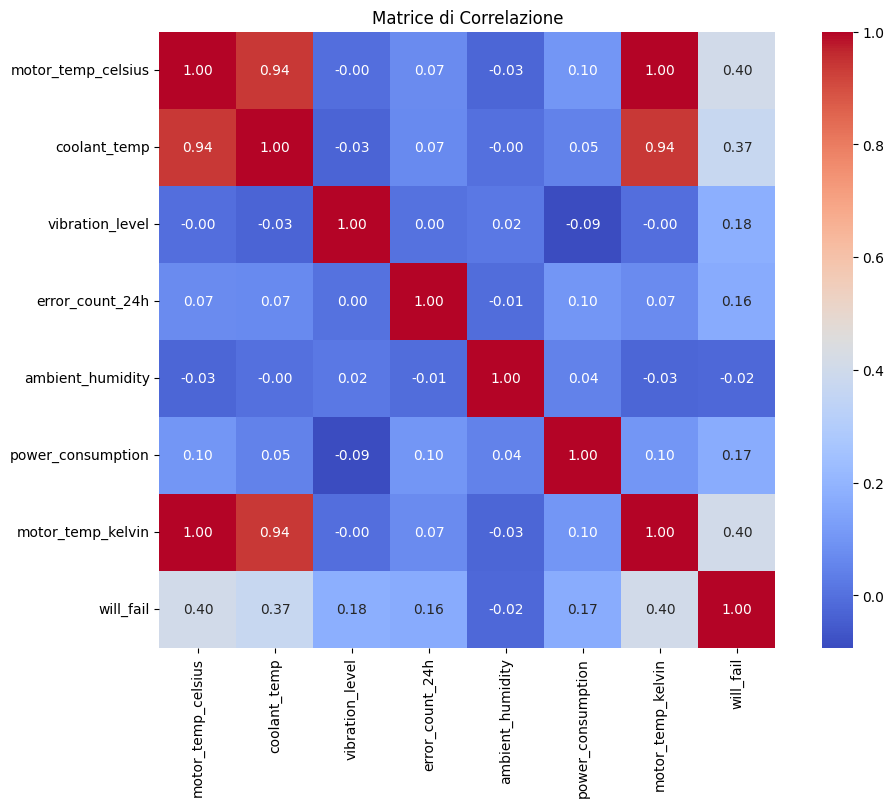

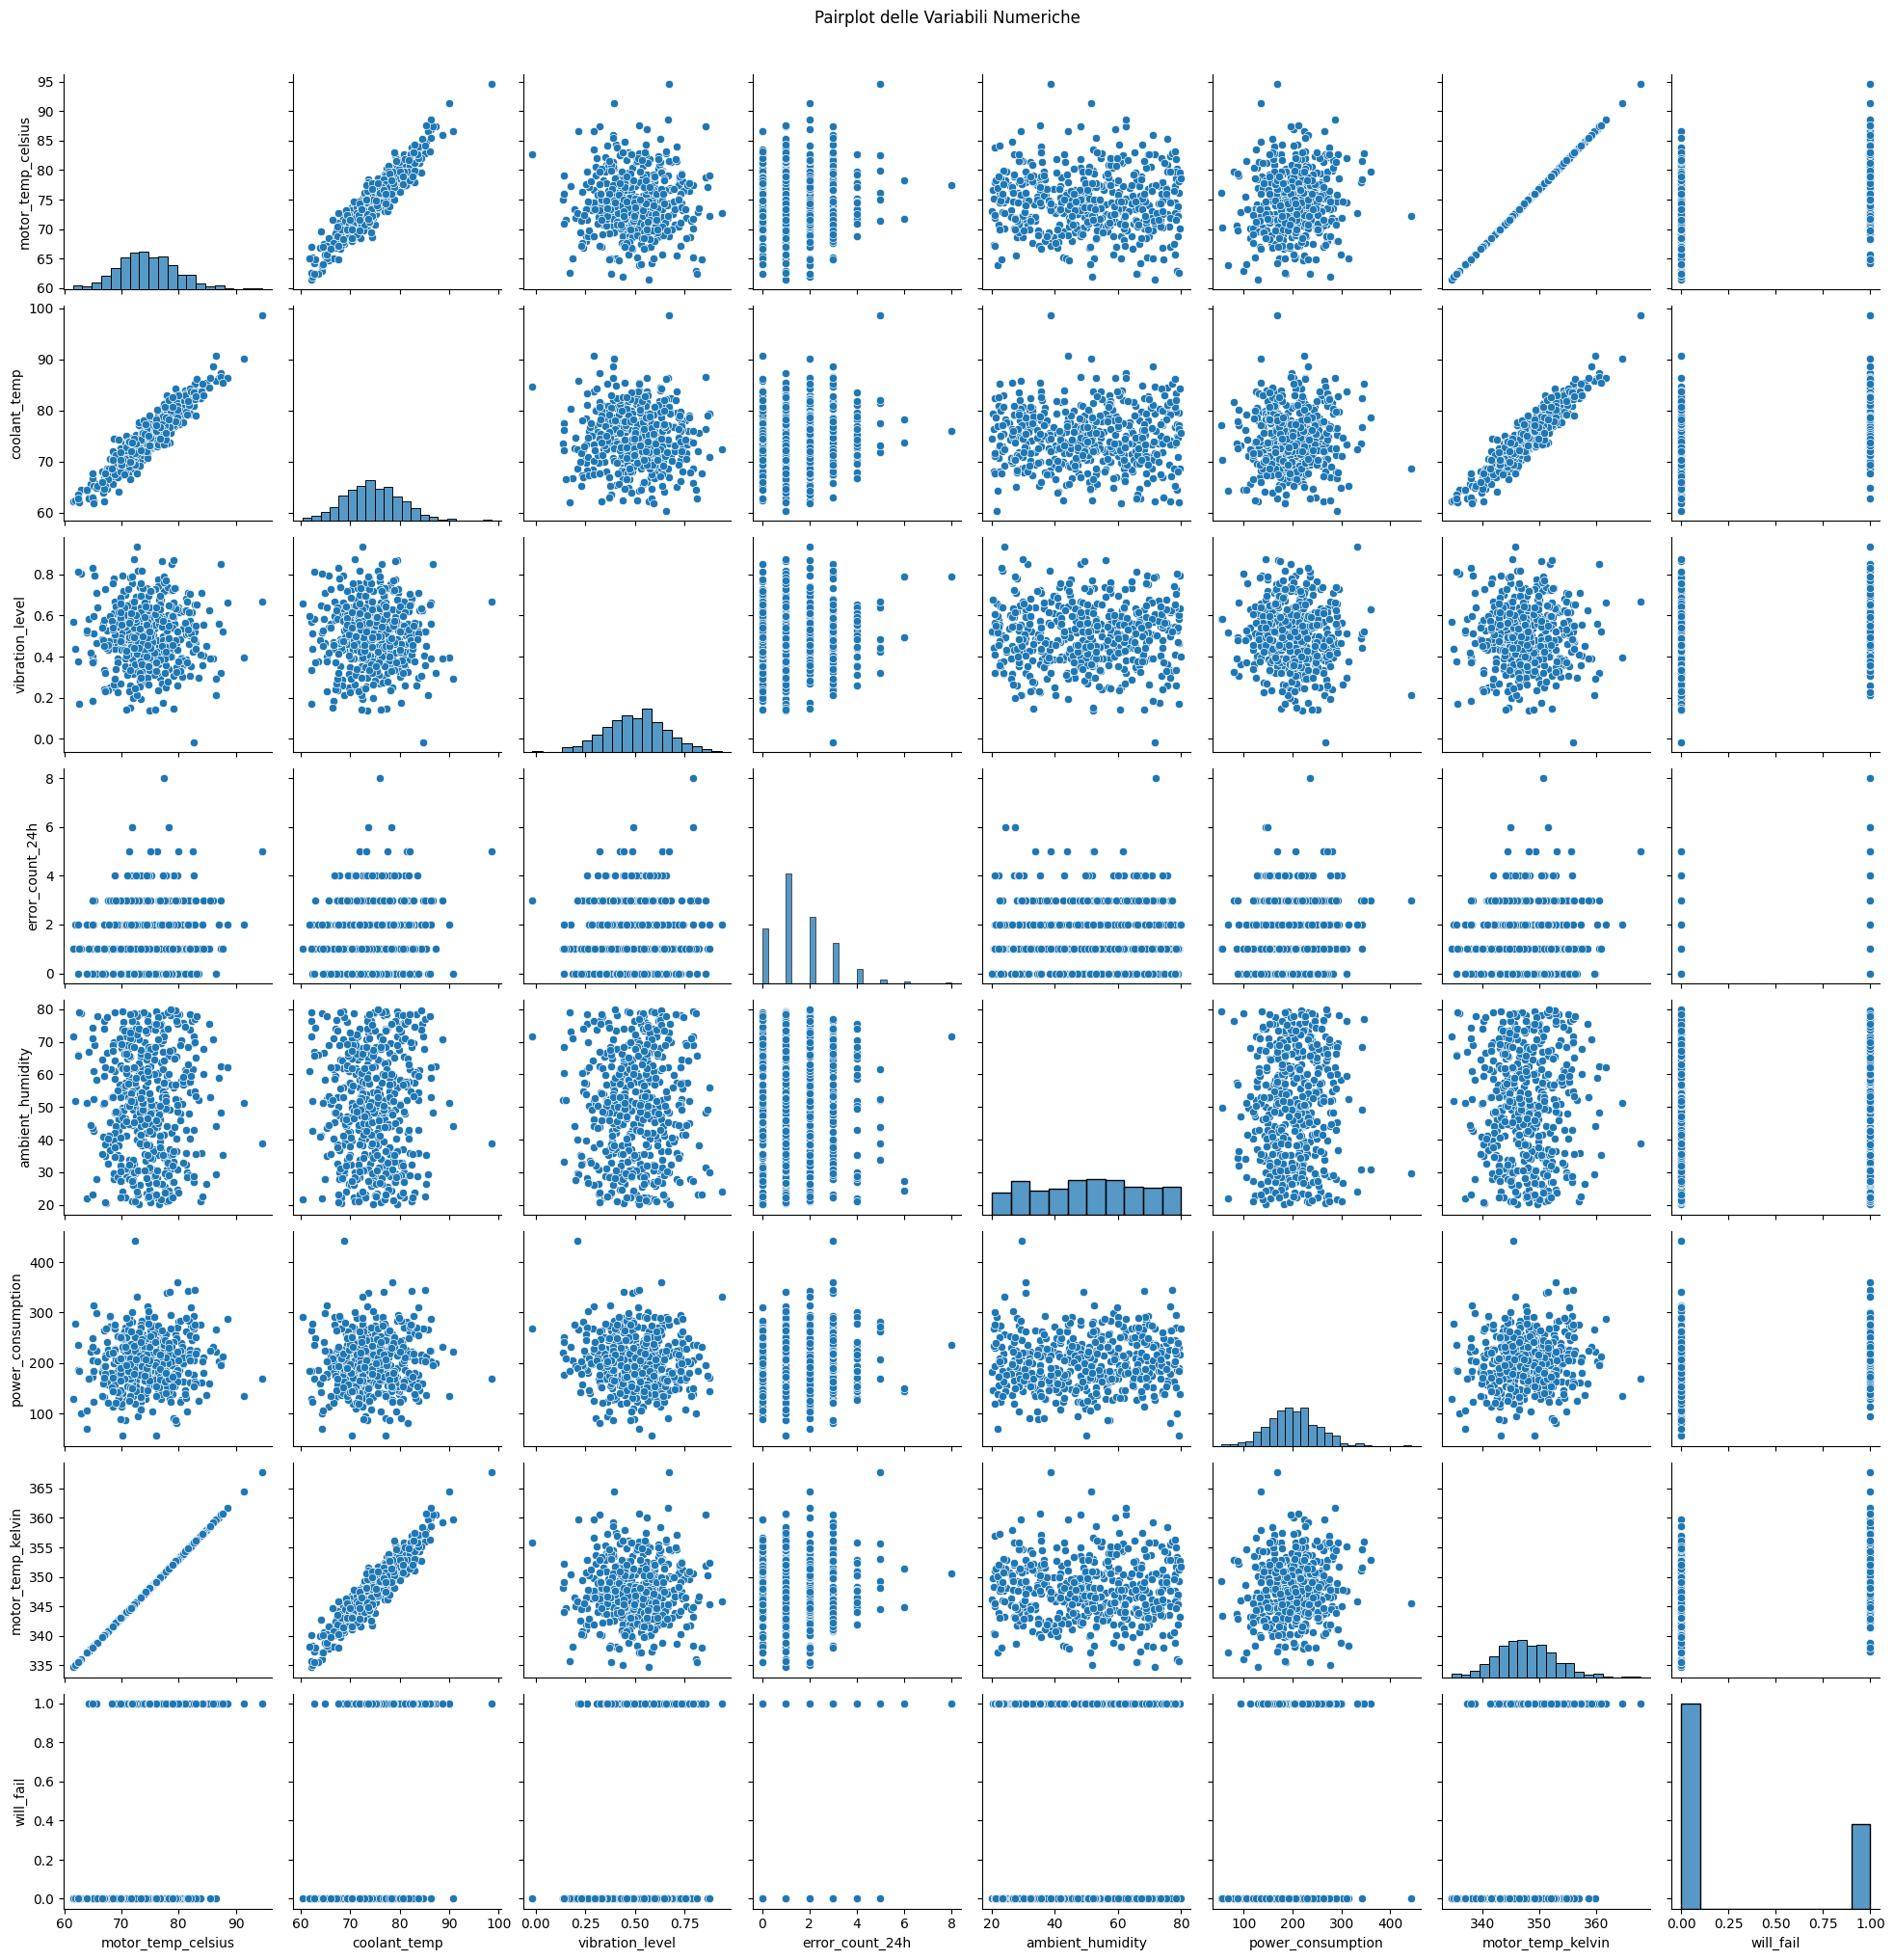

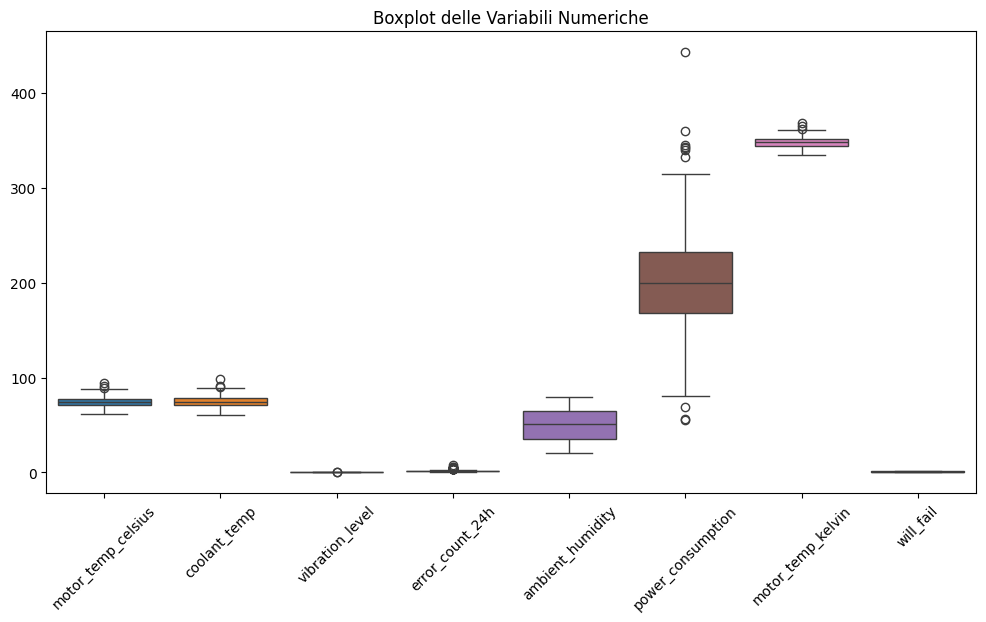

Conteggio per operating_mode:
operating_mode
Auto      294
Manual    105
Idle      101
Name: count, dtype: int64

Conteggio per maintenance_flag:
maintenance_flag
Base       312
Done       143
Overdue     45
Name: count, dtype: int64



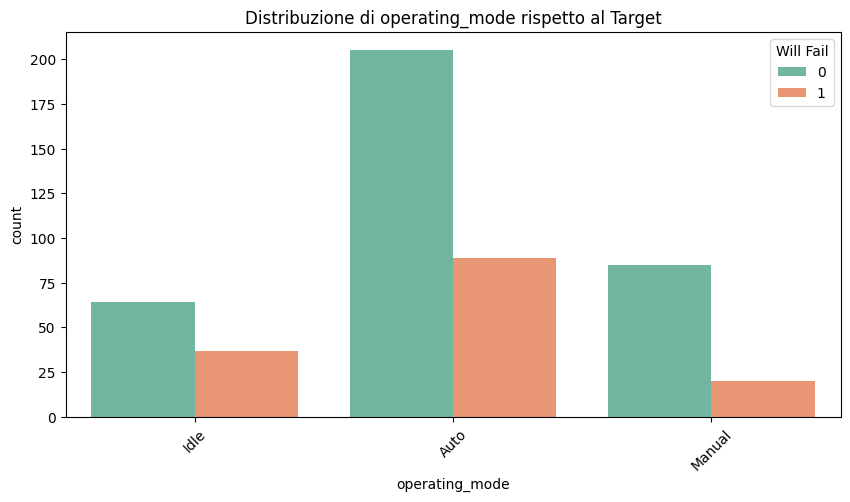

Proporzione di (classe positiva)/(classe positiva + negativa) per operating_mode:
operating_mode
Auto      0.302721
Idle      0.366337
Manual    0.190476
Name: will_fail, dtype: float64



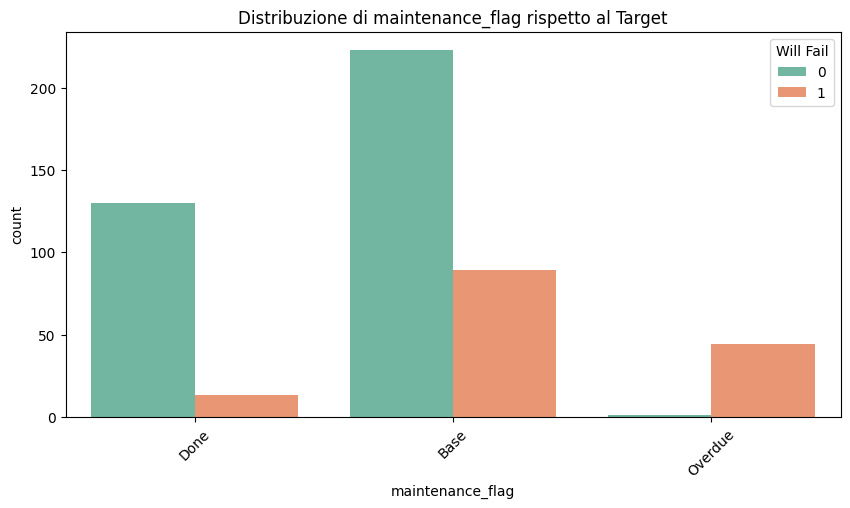

Proporzione di (classe positiva)/(classe positiva + negativa) per maintenance_flag:
maintenance_flag
Base       0.285256
Done       0.090909
Overdue    0.977778
Name: will_fail, dtype: float64



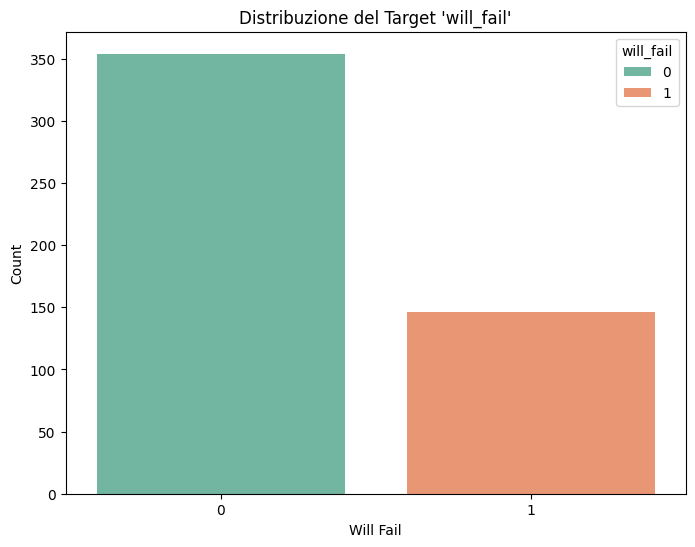

Proporzione di (classe positiva)/(classe positiva + negativa)  0.29


In [6]:
#Soluzione 1: 
# 1) descrizione del dataset (opzionale)
data_summary = data.describe(include='all').transpose()
display(data_summary)

# 2) conteggio dei NaN 
nan_count = data.isna().sum() 
print(f"Numero di NaN per colonna:\n{nan_count}")

# 3) variabili categoriche vs numeriche
# si può usare data.dtypes, o da unique values 
categorical_vars = data.select_dtypes(include=['object']).columns.tolist()
print(f"Variabili categoriche: {categorical_vars}")

# -- Analisi variabili numeriche ---
# 4) correlazione tra variabili numeriche 
num_data = data.drop(columns=categorical_vars)
corr_matrix = num_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Matrice di Correlazione")
plt.show()

# 5) pairplot 
sns.pairplot(num_data)
plt.suptitle("Pairplot delle Variabili Numeriche", y=1.02)
plt.show()

# 6) boxplot (per vedere outlier)
plt.figure(figsize=(12, 6))
sns.boxplot(data=num_data)
plt.title("Boxplot delle Variabili Numeriche")
plt.xticks(rotation=45)
plt.show()

# conclusioni: 
# Analisi dei NaN values; ci sono pochi NaN sulle 'temperature', quindi si possono eliminare le righe o fare imputazione con la media (dato che sono numeriche).
# 
# variabili continue: 
# la maggior parte ha distribuzione a campana, ad eccezione di ambient_humidity che ha una distribuzione uniforme.
# power_consumption presenta degli outliers, si vede dai boxplot. 
# motor_temp_celsius e motor_temp_kelvin sono equivalenti, a meno di uno shift, quindi si può eliminare una delle due
# la correlazione tra coolant_temp e motor_temp è molto alta, si può decidere di eliminare una delle due. Questo può essere utile perché 
# c'è un numero limitato di campioni, e riducendo il numero di variabili si riduce il rischio di overfitting.
# la correlazione tra ambient_humidity e will_fail è circa 0, quindi si può eliminare, perché non porta informazione. 

# variabili categoriche 
# 7) conteggio dei sample per categoria, per ogni variabile categorica
for col in categorical_vars:
    value_counts = data[col].value_counts()
    print(f"Conteggio per {col}:\n{value_counts}\n")

# 8) relazione tra variabili categoriche e target
for col in categorical_vars:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=data, x=col, hue='will_fail', palette='Set2')
    plt.title(f"Distribuzione di {col} rispetto al Target")
    plt.xticks(rotation=45)
    plt.legend(title='Will Fail')
    plt.show()

    # calcola la proporzione di will_fail per ogni categoria
    prop_will_fail = data.groupby(col)['will_fail'].mean()
    print(f"Proporzione di (classe positiva)/(classe positiva + negativa) per {col}:\n{prop_will_fail}\n")


# Conclusioni: 
# Usando **questa** realizzazione del dataset, notiamo che: il rapporto tra classe 0 e 1 di will_fail 
# è diverso tra le varie categorie di una variabile categorica. Questo suggerisce che le variabili 
# categoriche hanno una relazione con il target. Può capitare che con altre realizzazioni, il rapporto
# sia costante. In tale caso, la relazione è nulla/debole. 

# Analisi del target 
# 9) distribuzione del target
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='will_fail', hue='will_fail', palette='Set2')
plt.title("Distribuzione del Target 'will_fail'")
plt.xlabel("Will Fail")
plt.ylabel("Count")
plt.show()
# 10) rapporto tra classi del target
proportion_target = data['will_fail'].mean()
print(f"Proporzione di (classe positiva)/(classe positiva + negativa)  {proportion_target:.2f}")

# Conclusioni: 
# Il target è sbilanciato, la classe negativa (0) è maggioritaria. Si potrebbero usare tecniche di 
# over-sampling o under-sampling per bilanciare il dataset. Si deve usare stratified sampling per il
# train-test split per una valutazione corretta del modello. L'accuracy non è la metrica più adeguata,
# altre metriche come precision, recall, f1-score e ROC-AUC sono più adatte per dataset sbilanciati. 
# 
# NOTA: se il rapporto tra classi del target in una categoria è diverso da quello del target complessivo,
# si può dire che la variabile categorica ha informazione utile per il modello per predire il target. 

<span style="color:red"><strong>TODO 2</strong></span>: implementa gli step di preprocessing necessari per allenare un modello di machine learning. 
Motiva le scelte fatte con dei commenti. 

In [7]:
# Risposta 2: 
...

In [8]:
# Soluzione 2:
# pre-processing 
# 1. eliminazione variabili poco informative (motor_temp_kelvin, ambient_humidity, coolant_temp)
preprocessed_data = data.drop(columns=['motor_temp_kelvin', 'ambient_humidity', 'coolant_temp'])

# 2. imputazione dei NaN con la media (dato che sono numeriche) 
preprocessed_data['motor_temp_celsius'] = preprocessed_data['motor_temp_celsius'].fillna(preprocessed_data['motor_temp_celsius'].mean())
preprocessed_data['vibration_level'] = preprocessed_data['vibration_level'].fillna(preprocessed_data['vibration_level'].mean())


# 3. Encoding delle variabili categoriche 
preprocessed_data = pd.get_dummies(preprocessed_data, columns=['operating_mode'], drop_first=True)
preprocessed_data['maintenance_flag'] = preprocessed_data['maintenance_flag'].astype('category').cat.codes

display(preprocessed_data.head())

,motor_temp_celsius,vibration_level,error_count_24h,power_consumption,maintenance_flag,will_fail,operating_mode_Idle,operating_mode_Manual
0,70.116612,0.489291,2,257.460841,1,0,True,False
1,79.435399,0.463548,2,190.590401,0,1,False,False
2,69.548039,0.622376,3,187.370721,0,0,False,False
3,75.208357,0.579528,4,155.475327,1,0,False,False
4,74.354829,0.513996,1,145.593700,0,0,False,False


## 2. Modellizzazione e algoritmi fondamentali

### Feed Forward Neural Network

**⚠️ [Ti serve il dataset del punto precedente]**

Vogliamo allenare una rete neurale  il target `y` del punto precedente `will_fail`. In particolare, vogliamo allenare una feed-forward neural network. 

Le specifiche del modello sono le seguenti: 
- Architettura: scegli un numero di layer e neuroni che ritieni adeguato. Scegli i tipi di layer che ritieni più adeguati. 
- Funzione di attivazione: usa `ReLU` per i layer nascosti. 
- Layer di output: 1 neurone, con attivazione `sigmoid`. Il neurone restituisce in output la probabilità che il target sia `1`. 
- Ottimizzatore: `Adam`, con un learning rate di `0.001`.  
- Funzione di loss: `binary_crossentropy`. 
- Iperparametri come il numero di epoche (`epochs`) e la dimensione del batch (`batch size`) sono a tua discrezione. 

**Opzionale**: puoi utilizzare TensorBoard per monitorare metriche aggiuntive durante l'allenamento. 

<span style="color:red"><strong>TODO 3</strong></span>: 

- <span style="color:red"><strong>3.1</strong></span>: Implementa il modello come descritto sopra. Metti dei commenti per motivare la scelta della tipologia dei layer. Usa il framework che preferisci (Keras o PyTorch)
- <span style="color:red"><strong>3.2</strong></span>: Dividi il dataset della parte 1 in train e test. Non serve che usi cross-validation per valutare le performance. Attenzione: potrebbe servirti ulteriore pre-processing! 
- <span style="color:red"><strong>3.3</strong></span>: Allena il modello sul training set. 
- <span style="color:red"><strong>3.4</strong></span>: Valuta le perfomance di generalizzazione usando metriche adeguate. Nota: puoi usare accuracy durante il train, e le metriche più adeguate solo nel test. Commenta i risultati ottenuti. 

In [9]:
# Risposta 3.1: 
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, MaxPooling2D, BatchNormalization, Conv2D, AvgPool1D
from tensorflow.keras.losses import BinaryCrossentropy

# Scegliamo le metriche più adatte da questa lista, aggiungile a metrics=['accuracy', 'Metrica1',...]
# in alternativa usa solo accuracy e poi implementa le metriche a mano sulla fase di valutazione delle performance di generalizzazione 
# del modello 
print(dir(tensorflow.keras.metrics))

['AUC', 'Accuracy', 'BinaryAccuracy', 'BinaryCrossentropy', 'BinaryIoU', 'CategoricalAccuracy', 'CategoricalCrossentropy', 'CategoricalHinge', 'CosineSimilarity', 'F1Score', 'FBetaScore', 'FalseNegatives', 'FalsePositives', 'Hinge', 'IoU', 'KLD', 'KLDivergence', 'LogCoshError', 'MAE', 'MAPE', 'MSE', 'MSLE', 'Mean', 'MeanAbsoluteError', 'MeanAbsolutePercentageError', 'MeanIoU', 'MeanMetricWrapper', 'MeanSquaredError', 'MeanSquaredLogarithmicError', 'Metric', 'OneHotIoU', 'OneHotMeanIoU', 'Poisson', 'Precision', 'PrecisionAtRecall', 'R2Score', 'Recall', 'RecallAtPrecision', 'RootMeanSquaredError', 'SensitivityAtSpecificity', 'SparseCategoricalAccuracy', 'SparseCategoricalCrossentropy', 'SparseTopKCategoricalAccuracy', 'SpecificityAtSensitivity', 'SquaredHinge', 'Sum', 'TopKCategoricalAccuracy', 'TrueNegatives', 'TruePositives', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'binary_accuracy', 'binary_crossentropy', 'b

In [10]:
# Soluzione 3.1: 
from tensorflow.nn import weighted_cross_entropy_with_logits

def create_model(n_features, compile=True): 
    model = Sequential([
        Input(shape=(n_features,)), 
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='sigmoid')   
        # per binary classification, attivazione con sigmoide va bene. 
        # si potrebbero anche usare 2 neuroni, softmax e sparse categorical cross entropy 
        # come su multiclass, ma non è necessario. 
    ])
    if compile: 
        model.compile(
            loss = 'binary_crossentropy', 
            optimizer = 'adam',
            metrics = ['accuracy', 'Precision', 'Recall', 'AUC']
        )
    return model

In [11]:
# Risposta 3.2: 
np.random.seed(n_matricola)
from exam_utils import random_train_test_split, stratified_train_test_split
...

#NOTE: se vuoi convertire i dataframe i array di numpy, usa
# X = X_df.to_numpy(dtype=np.float32) e y = y_df.to_numpy(dtype=np.int64) 
# per evitare errori durante il training del modello. 

Ellipsis

In [12]:
# Soluzione 3.2:
Xdf = preprocessed_data.drop(columns=['will_fail'])
ydf = preprocessed_data['will_fail']
X = Xdf.to_numpy(dtype=np.float32)
y = ydf.to_numpy(dtype=np.int64)

# dividere in train e test set usando stratified sampling 
X_train, X_test, y_train, y_test = stratified_train_test_split(X, y, train_prop=0.8)

# normalizzare le feature continue
display(Xdf.head(1)) 
numerical_feat_idx = [0, 1, 2, 3]
X_cont_mean = np.mean(X_train[:, numerical_feat_idx], axis=0)
X_std_mean = np.std(X_train[:, numerical_feat_idx], axis=0)
X_train[:, numerical_feat_idx] = (X_train[:, numerical_feat_idx] - X_cont_mean) / X_std_mean
X_test[:, numerical_feat_idx] = (X_test[:, numerical_feat_idx] - X_cont_mean) / X_std_mean

,motor_temp_celsius,vibration_level,error_count_24h,power_consumption,maintenance_flag,operating_mode_Idle,operating_mode_Manual
0,70.116612,0.489291,2,257.460841,1,True,False


In [13]:
# Risposta 3.3: 
...

In [14]:
# Soluzione 3.3: 
model = create_model(X.shape[1], compile=True)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - AUC: 0.6086 - Precision: 0.4075 - Recall: 0.5683 - accuracy: 0.5588 - loss: 0.7517 - val_AUC: 0.7410 - val_Precision: 0.3810 - val_Recall: 0.7273 - val_accuracy: 0.6000 - val_loss: 0.6586
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.7625 - Precision: 0.4365 - Recall: 0.7284 - accuracy: 0.6653 - loss: 0.6156 - val_AUC: 0.8103 - val_Precision: 0.5172 - val_Recall: 0.6818 - val_accuracy: 0.7375 - val_loss: 0.6222
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8225 - Precision: 0.5712 - Recall: 0.8071 - accuracy: 0.7500 - loss: 0.5368 - val_AUC: 0.8495 - val_Precision: 0.5769 - val_Recall: 0.6818 - val_accuracy: 0.7750 - val_loss: 0.5936
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.8283 - Precision: 0.5859 - Recall: 0.7501 - accuracy: 0.7432 - loss: 0.5068 - val_AUC: 0.8558 - val_Precision: 0.6522 - val_Recall: 0.6818 - val_accuracy: 0.8125 - val_loss: 0.5685
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0

In [15]:
# Riposta 3.4: 
...

Test Loss: 0.3281
Test Accuracy: 0.8317
Test Precision: 0.8824
Test Recall: 0.5000
Test AUC: 0.9369
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


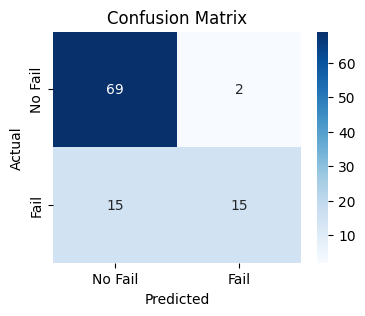

In [16]:
# Soluzione 3.4:
test_loss, accuracy, precision, recall, auc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}"
      f"\nTest Accuracy: {accuracy:.4f}"
      f"\nTest Precision: {precision:.4f}"
      f"\nTest Recall: {recall:.4f}"
      f"\nTest AUC: {auc:.4f}")

# (opzionale): predizioni e confusion matrix
from sklearn.metrics import confusion_matrix
y_pred_test = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fail', 'Fail'], yticklabels=['No Fail', 'Fail'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# il modello presenta un recall vicino a 0.5 e una precisione alta. Questo suggerisce che
# quando predice una classe positiva, quasi sempre è corretta la predizione. Questo si può vedere 
# dalla confusion matrix plottata sotto, dove di 18 predetti positivi, 16 sono veri positivi. 
# Il recall intorno 0.5 indica che, se il campione è positivo nella realtà, il modello spesso fa
# una predizione random ovvero predice con la stessa probabilità la classe 0 o 1. Questo si vede 
# nella seconda riga della confusion matrix, dove di 30 campioni positivi, 16 sono predetti come 
# positivi e 14 come negativi (sbagliando). 

# Il recall basso è dovuto allo sbilanciamento del target, che presenta molti meno campioni 
# appartenenti alla classe positiva. Nell'ottimizzazione, il modello riduce di più la loss totale
# se predice in modo migliore la classe più presente.

# NOTA PRATICA: in scenari safety-critical, spesso si preferisce avere un recall più alto, 
# a discapito della precisione, perché si preferiscono più falsi positivi che falsi negativi, 
# per questioni di sicurezza (è meglio effettuare una manutenzione/controllo superflui che 
# riparare i danni di un fallimento)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - AUC: 0.5088 - Precision: 0.3181 - Recall: 0.5343 - accuracy: 0.4676 - loss: 1.2069 - val_AUC: 0.6611 - val_Precision: 0.8333 - val_Recall: 0.2273 - val_accuracy: 0.7750 - val_loss: 1.1370
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.6869 - Precision: 0.3506 - Recall: 0.6486 - accuracy: 0.5705 - loss: 1.1047 - val_AUC: 0.8049 - val_Precision: 0.6316 - val_Recall: 0.5455 - val_accuracy: 0.7875 - val_loss: 1.1250
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.7479 - Precision: 0.4279 - Recall: 0.7681 - accuracy: 0.6363 - loss: 1.0810 - val_AUC: 0.8460 - val_Precision: 0.5862 - val_Recall: 0.7727 - val_accuracy: 0.7875 - val_loss: 1.1145
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8266 - Precision: 0.5251 - Recall: 0.8795 - accuracy: 0.7349 - loss: 1.0423 - val_AUC: 0.8578 - val_Precision: 0.4500 - val_Recall: 0.8182 - val_accuracy: 0.6750 - val_loss: 1.1052
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0

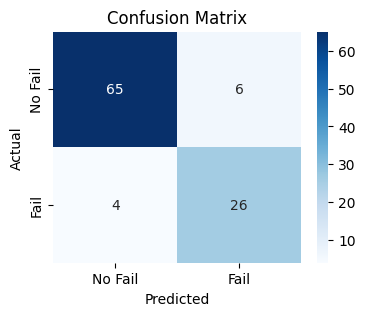

In [17]:
# BONUS: per bilanciare precision e recall, possiamo usare una weighted loss, che penalizza di più la classe minoritaria (1). 
from tensorflow.nn import weighted_cross_entropy_with_logits

def create_model_bonus(n_features, compile=True, y_train=None): 
    model = Sequential([
        Input(shape=(n_features,)), 
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='sigmoid')   
        # per binary classification, attivazione con sigmoide va bene. 
        # si potrebbero anche usare 2 neuroni, softmax e sparse categorical cross entropy 
        # come su multiclass, ma non è necessario. 
    ])
    if compile: 
        model.compile(
            loss = lambda labels, logits: weighted_cross_entropy_with_logits(labels=labels, logits=logits, pos_weight=1/y_train.mean()), 
            optimizer = 'adam',
            metrics = ['accuracy', 'Precision', 'Recall', 'AUC']
        )
    return model

model_bonus = create_model_bonus(X.shape[1], compile=True, y_train=y_train)
model_bonus.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

test_loss, accuracy, precision, recall, auc = model_bonus.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}"
      f"\nTest Accuracy: {accuracy:.4f}"
      f"\nTest Precision: {precision:.4f}"
      f"\nTest Recall: {recall:.4f}"
      f"\nTest AUC: {auc:.4f}")

# (opzionale): predizioni e confusion matrix
from sklearn.metrics import confusion_matrix
y_pred_test = (model_bonus.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fail', 'Fail'], yticklabels=['No Fail', 'Fail'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Agglomerative Hierarchical Clustering

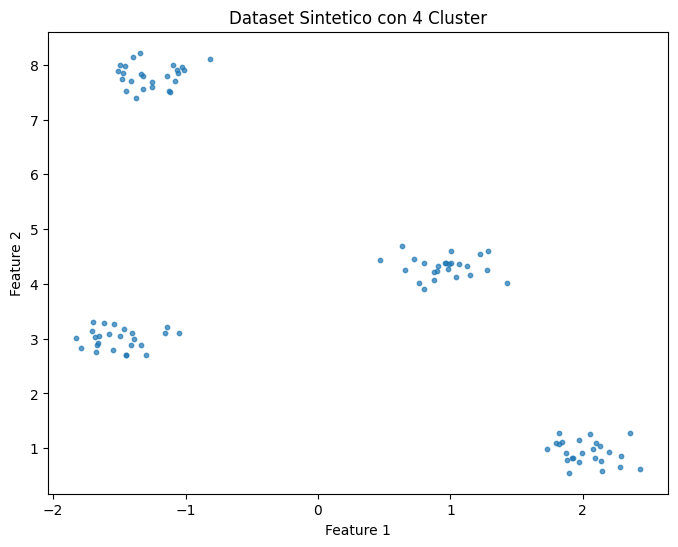

In [18]:
# creiamo un dataset sintetico e già pulito
from sklearn.datasets import make_blobs 
X_blobs, _ = make_blobs(n_samples=100, centers=4, cluster_std=0.2, random_state=n_matricola)

plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=10, alpha=0.7)
plt.title("Dataset Sintetico con 4 Cluster")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


<span style="color:red"><strong>TODO 4</strong></span>: 

- <span style="color:red"><strong>TODO 4.1</strong></span>: Scrivi lo pseudocodice dell'algoritmo di Agglomerative Hierarchical clustering, visto in classe e in laboratorio. Usa la *distanza media* come criterio per unire i due cluster.  
-  <span style="color:red"><strong>TODO 4.2</strong></span>: Implementa il codice. Puoi usare la funzione implementata sotto. 
- <span style="color:red"><strong>TODO 4.3 </strong></span>: Applica il modello ai dati. 
- <span style="color:red"><strong>TODO 4.4 (opzionale)</strong></span>: Plotta i risultati del tuo algoritmo per verificare che stia funzionando correttamente.


In [19]:
# Risposta 4.1: 
...

In [20]:
# Soluzione 4.1:
# vedi sotto

In [21]:
# Risposta 4.2 (su materiale addizionale dato durante l'esame):
def average_cluster_distance(C1, C2): 
    """
    Compute the distance between the two clusters using Euclidean distance for points. 
    
    Args:
        C1: np.ndarray - points in the first cluster, shape (n1, n_features)
        C2: np.ndarray - points in the second cluster, shape (n2, n_features)
    
    Returns:
        float - the average linkage distance between the two clusters
    """
    dist = 0 
    for i in range(C1.shape[0]): 
        for j in range(C2.shape[0]): 
            dist += np.linalg.norm(C1[i] - C2[j])
    dist = dist / (C1.shape[0] * C2.shape[0])
    return dist

In [22]:
# Soluzione 4.2:
class AgglomerativeHierarchicalClustering: 
    """Agglomerative Hierarchical Clustering con Average Linkage e distanza euclidea"""

    def __init__(self, n_clusters): 
        self.n_clusters = n_clusters
        self.cmatrix = None
        self.centroids = None
        self.X_train = None
        

    def fit(self, X): 
        """
        Fit del modello e salva la matrice di assegnazione dei cluster. Ritorna i centroidi dei cluster.
        Args:
            X: np.ndarray - dati da clusterizzare, shape (n_samples, n_features)
            n_clusters: int - numero di cluster da creare.
        """
        self.X_train = X
        self._build_clusters(self.n_clusters)
        self.centroids = self.get_centroids(self.n_clusters)
    
    def _build_clusters(self, n_clusters): 
        """
        Esegue l'aggregazione dei cluster fino a quando non rimangono n_clusters cluster e salva
        la matrice di assegnazione dei cluster ad ogni passo.
        """
        n_samples, n_features = self.X_train.shape

        # per avere n_clusters cluster dobbiamo fare n_samples-n_clusters iterazioni 
        n_iters = n_samples - n_clusters

        # inizializzare la cmatrix e la lista dei cluster: ogni sample costituisce un cluster all'inizio 
        self.cmatrix = np.zeros((n_iters + 1, n_samples), dtype=int)        # vogliamo salvare anche lo stato iniziale (+1)
        self.cmatrix[0, :] = np.arange(n_samples) 
        clusters = [[i] for i in range(n_samples)]   

        # iterare fino a che non abbiamo n_clusters rimasti  
        for i in range(1, n_iters + 1): 
            # trova i due cluster più vicini
            best_pair = (None, None)
            min_dist = np.inf
            for j in range(len(clusters)):
                for k in range(j+1, len(clusters)):     # non serve controllare la stessa coppia due volte
                    Cj = self.X_train[clusters[j]]
                    Ck = self.X_train[clusters[k]]
                    dist = average_cluster_distance(Cj, Ck)
                    if dist < min_dist:
                        best_pair = (j, k)
                        min_dist = dist
            
            # unire i due cluster più vicini
            j, k = best_pair
            clusters[j] += clusters[k]                  # aggiungiamo gli indici dei sample nel cluster k al cluster j
            del clusters[k]                             # rimuoviamo il cluster/list k

            # aggiorna la riga i-esima della cmatrix 
            labels = np.zeros(n_samples, dtype=int)     # per ogni sample dobbiamo assegnare la nuova etichetta del cluster
            for cluster_idx, clust in enumerate(clusters):  
                for sample_idx in clust:
                    labels[sample_idx] = cluster_idx
            self.cmatrix[i, :] = labels

                        
    def get_centroids(self, n_clusters): 
        """
        Calcola i centroidi dei cluster usando il training set e la cmatrix. Il centroide è il 
        baricentro del cluster. Nota: cmatrix[i,:] contiene le etichette dei cluster per n_samples-i cluster.
        Per ottenere la riga per n_clusters cluster, dobbiamo prendere la riga n_samples-n_clusters.

        Returns:
            np.ndarray - array di shape (n_clusters, n_features) contenente i centroidi dei cluster
        """
        labels = self.cmatrix[self.X_train.shape[0]-n_clusters, :]
        centroids = np.zeros((n_clusters, self.X_train.shape[1]))
        for i in range(n_clusters): 
            # prendi i valori dei sample nel cluster i
            indices = (labels == i)
            samples = self.X_train[indices]
            # calcola il baricentro
            centroids[i,:] = np.mean(samples, axis=0)
        return centroids
    
    def predict(self, X, n_clusters=None): 
        """
        OPZIONALE: non seriva per l'esame

        Predice la label per i campioni in X scegliendo il cluster del centroide più vicino.
        Se n_clusters non è specificato, utilizzerà il numero di cluster usato in fit. 
        Altrimenti, ricalcolerà i centroidi per il nuovo numero di cluster dalla cmatrix. 
        
        Args: 
            X: np.ndarray - data a cui assegnare le label, shape (n_samples, n_features)
            n_clusters: int - numero di cluster da usare per la predizione. Se None, usa il numero di cluster usato in fit.
        """
        if n_clusters is None: 
            centroids = self.centroids
        else: 
            if n_clusters > self.cmatrix.shape[0]: 
                raise ValueError("n_clusters must be less than or equal to the number of clusters used in fit.")
            centroids = self.get_centroids(n_clusters)

        labels = np.zeros(X.shape[0], dtype=int)
        for i in range(X.shape[0]): 
            # calcola la distanza tra il sample e tutti i centroidi
            dists = [np.linalg.norm(X[i] - c) for c in centroids]
            # assegna la label del cluster più vicino
            labels[i] = np.argmin(dists)
        return labels


In [23]:
# Risposta 4.3: 
...

In [24]:
# Soluzione 4.3:
model = AgglomerativeHierarchicalClustering(n_clusters=4)
model.fit(X_blobs)

In [25]:
# Risposta 4.4: 
... 

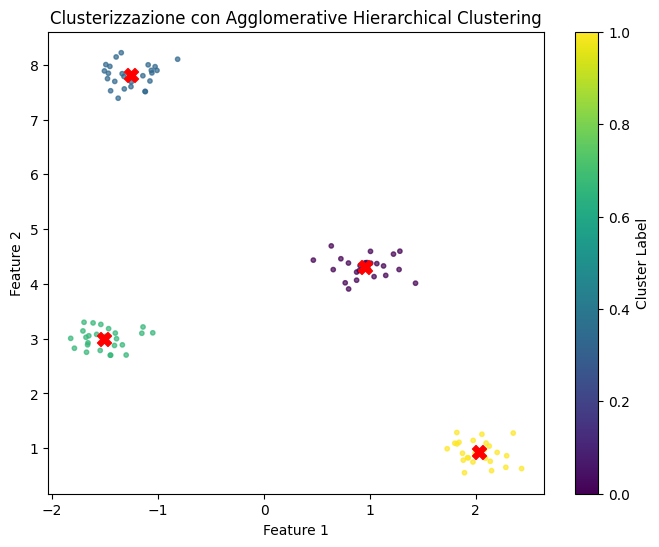

In [26]:
# Soluzione 4.4:
cluster_labels = model.cmatrix[-1, :]
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=cluster_labels, cmap='viridis', s=10, alpha=0.7)
plt.scatter(model.centroids[:, 0], model.centroids[:, 1], c='red', marker='X', s=100, label='Centroids')
plt.title("Clusterizzazione con Agglomerative Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label='Cluster Label')
plt.show()

<span style="color:red"><strong>TODO 5</strong></span>: Se un dataset ha $n$ samples, e vogliamo ottenere $m$ clusters, quante iterazioni di questa versione *agglomerative* di hierarchical clustering sono necessarie?

<span style="color:red"><strong>Risposta 5:</strong></span>
```
n_samples - n_clusters 
```

## 3. Nuovo algoritmo: versione top-down di hierarchical clustering

L'algoritmo di hierarchical clustering precedente, detto *agglomerative*, costruisce una gerarchia **bottom-up**, cioè parte considerando ogni punto come un cluster distinto, per poi unirli. 

Si vuole ora esplorare una strategia alternativa, detta *divisive*, che costruisce la gerarchia in modo **top-down**. 

<span style="color:red"><strong>TODO 6</strong></span>: 
- <span style="color:red"><strong>TODO 6.1</strong></span>: Descrivi come si potrebbe comportare un algoritmo divisivo, partendo da un unico cluster contenente tutti i punti. Scrivendo in pseudocodice, proponi una strategia per suddividere i cluster, tenendo conto del fatto che si vogliono ottenere esattamente $m$ cluster. Spiega:
    - quale cluster andrebbe diviso ad ogni passo? 
    - con quale criterio divideresti i punti di un cluster? 
- <span style="color:red"><strong>TODO 6.2</strong></span>: implementa il codice dell'algoritmo. 
- <span style="color:red"><strong>TODO 6.3</strong></span>: applica il modello a `X_blob`. 
- <span style="color:red"><strong>TODO 6.4 (Opzionale) </strong></span>: visualizza i risultati. 

In [27]:
# Risposta 6.1
...

In [28]:
# Risposta 6.2 
...

In [29]:
# Risposta 6.3
...

In [30]:
# Risposta 6.4
...

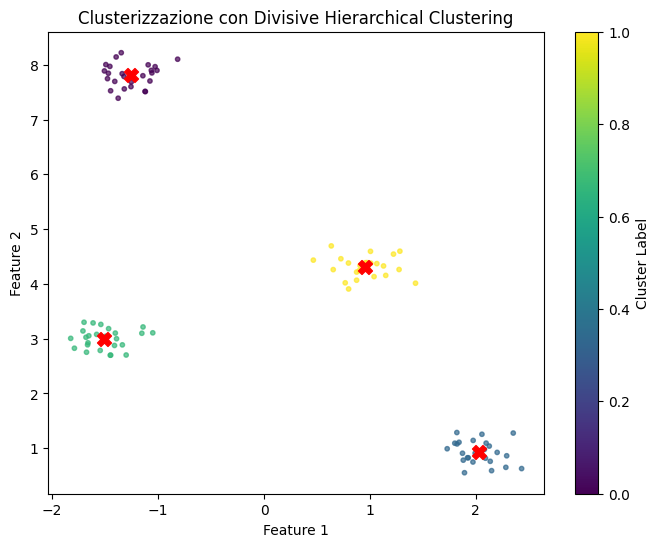

In [ ]:
# Soluzione 6.1 
# In modo ricorsivo/iterativo: 
# 1) scegliamo il cluster da dividere, che è quello con la dispersione più alta, per esempio quello la cui media 
#    della distanza euclidea tra le coppie di punti del cluster è più alta.
# 2) dividi i punti del cluster in due sotto-cluster, usando KMeans. 

# Soluzione 6.2:
class KMeans: 
    def __init__(self, n_clusters=2, max_iters=100, tol=1e-6, random_state=0): 
        self.k = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels_ = None
        self.rng = np.random.RandomState(random_state)  # per garantire la riproducibilità (non necessario per l'esame)
    
    def _assign_cluster(self, X): 
        """Assegna ogni punto al cluster con il centroide più vicino."""
        # calcola distanze tra ogni punto e i centroidi
        pairwise_distances = np.zeros((X.shape[0], self.centroids.shape[0]))
        for i in range(X.shape[0]): 
            for j in range(self.centroids.shape[0]): 
                pairwise_distances[i, j] = np.linalg.norm(X[i] - self.centroids[j]) 
        return np.argmin(pairwise_distances, axis=1)
    
    def _update_centroids(self, X, labels): 
        """Aggiorna i centroidi calcolando la media dei punti nel cluster"""
        return np.array([X[labels == i].mean(axis=0) for i in range(self.k)])

    def fit(self, X): 
        # inizializza i centroidi casualmente 
        self.centroids = X[self.rng.choice(X.shape[0], self.k, replace=False)]
        # inizializza le labels 
        labels_ = self._assign_cluster(X)

        for _ in range(self.max_iters): 
            # aggiorna i centroidi
            new_centroids = self._update_centroids(X, labels_)

            # controlla la convergenza
            if np.all(np.abs(new_centroids - self.centroids) < self.tol):
                break  
                
            # aggiorna i centroidi e le labels
            self.centroids = new_centroids
            labels = self._assign_cluster(X)
        
        self.labels_ = labels 
        return self


class DivisiveClustering: 
    """Divisive Hierarchical Clustering con KMeans per la divisione dei cluster"""
    def __init__(self, n_clusters, random_state=0): 
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.cmatrix = None
        self.centroids = None
        self.X_train = None

    def fit(self, X):
        """
        Fit del modello, salva la matrice di assegnazione dei cluster e i centroidi.
        """
        self.X_train = X
        self._build_clusters(self.n_clusters)
        self.centroids = self.get_centroids(self.n_clusters)
    
    def _build_clusters(self, n_clusters): 
        """
        Iterativamente divide i cluster in 2 usando KMeans (k=2) fino a quanto il numero di 
        cluster raggiunge n_clusters. Salva la matrice di assegnazione dei cluster ad ogni passo.

        """
        n_samples, n_features = self.X_train.shape
        max_iters = n_clusters - 1 # per ottenere n_clusters, dobbiamo fare n_clusters-1 iterazioni
        self.cmatrix = np.zeros((max_iters + 1, n_samples), dtype=int)

        # initializzazione: tutti i sample in un cluster (appartengono al cluster 0 )
        # self.cmatrix[0, :] = 0  # non serve perché inizializziamo con np.zeros
        clusters = {0: np.arange(n_samples)} # possiamo usare un dizionario al posto di una lista di liste!
        next_cluster_id = 1 # per i nuovi cluster che creiamo

        for i in range(1, max_iters + 1): 
            # step 1: scegli il cluster da dividere 
            max_dist = -1 
            cluster_to_split = None 
            for cluster_id, cluster_sample_idxs in clusters.items(): 
                if len(cluster_sample_idxs) < 2: 
                    continue # non possiamo dividere un cluster con 1 sample o meno 
                cluster_samples = self.X_train[cluster_sample_idxs, :] 
                distance = self._average_intra_cluster_distance(cluster_samples)
                if distance > max_dist: 
                    max_dist = distance
                    cluster_to_split = cluster_id
                
            if cluster_to_split is None: 
                break  # se non abbiamo trovato un cluster da dividere, usciamo 

            sample_indices = clusters[cluster_to_split]     # indici dei sample del cluster da dividere
            samples = self.X_train[sample_indices, :]       # campioni del cluster da dividere

            # step 2: dividiamo il cluster in due usando KMeans
            kmeans = KMeans(n_clusters=2, random_state=self.random_state)
            kmeans.fit(samples)
            labels = kmeans.labels_

            # step 3: aggiorniamo il dizionario dei cluster
            del clusters[cluster_to_split]  
            cluster_1_indices = sample_indices[labels == 0]
            cluster_2_indices = sample_indices[labels == 1]
            clusters[cluster_to_split] = cluster_1_indices
            clusters[next_cluster_id] = cluster_2_indices
            next_cluster_id += 1

            # step 4: aggiorniamo la matrice di assegnazione dei cluster
            new_labels = np.zeros(n_samples, dtype=int)
            for c_id, sample_indices in clusters.items():
                new_labels[sample_indices] = c_id
            self.cmatrix[i, :] = new_labels

    def _average_intra_cluster_distance(self, X):
        """ Calcola la distanza media intra-cluster tra i punti in X."""
        n = X.shape[0]
        if n < 2:
            return 0.0
        dists = 0
        for i in range(n):
            for j in range(i + 1, n):
                dists += np.linalg.norm(X[i] - X[j])
        return 2 * dists / (n * (n - 1))


    def get_centroids(self, n_clusters): 
        """
        Calcola i centroidi dei cluster a un certo livello di n_clusters. 
        """
        labels = self.cmatrix[n_clusters-1, :]
        centroids = np.zeros((n_clusters, self.X_train.shape[1]))
        for i in range(n_clusters): 
            # get the samples values in the cluster i
            indices = (labels == i)
            samples = self.X_train[indices]
            # compute the barycenter
            centroids[i,:] = np.mean(samples, axis=0)
        return centroids
    
    def predict(self, X, n_clusters=None): 
        """
        OPZIONALE: non seriva per l'esame

        Predice la label per i campioni in X scegliendo il cluster del centroide più vicino.
        Se n_clusters non è specificato, utilizzerà il numero di cluster usato in fit. 
        Altrimenti, ricalcolerà i centroidi per il nuovo numero di cluster dalla cmatrix. 
        
        Args: 
            X: np.ndarray - data a cui assegnare le label, shape (n_samples, n_features)
            n_clusters: int - numero di cluster da usare per la predizione. Se None, usa il numero di cluster usato in fit.
        """
        if n_clusters is None: 
            centroids = self.centroids
        else: 
            if n_clusters > self.cmatrix.shape[0]: 
                raise ValueError("n_clusters must be less than or equal to the number of clusters used in fit.")
            centroids = self.get_centroids(n_clusters)

        labels = np.zeros(X.shape[0], dtype=int)
        for i in range(X.shape[0]): 
            # calcola la distanza tra il sample e tutti i centroidi
            dists = [np.linalg.norm(X[i] - c) for c in centroids]
            # assegna la label del cluster più vicino
            labels[i] = np.argmin(dists)
        return labels

# Soluzione 6.3
model = DivisiveClustering(n_clusters=4, random_state=n_matricola)
model.fit(X_blobs)

# Risposta 6.4
cluster_labels = model.cmatrix[-1, :]
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=cluster_labels, cmap='viridis', s=10, alpha=0.7)
plt.scatter(model.centroids[:, 0], model.centroids[:, 1], c='red', marker='X', s=100, label='Centroids')
plt.title("Clusterizzazione con Divisive Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label='Cluster Label')
plt.show()